© 2026 by Tamás Takács is licensed under CC BY-NC-SA 4.0. To view a copy of this license, visit https://creativecommons.org/licenses/by-nc-sa/4.0/

# **The Blockworld Census**

**Deep Network Development W05**

**Topic:** NumPy and array programming

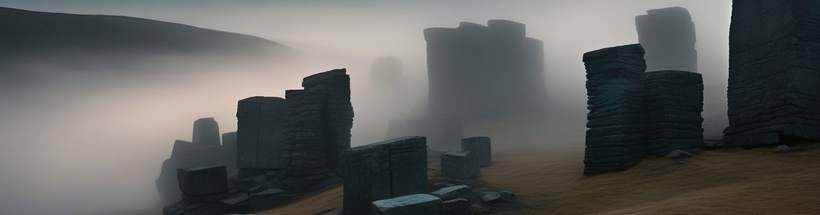

## **Situation Report**

The Kingdom of Cubes has a paperwork problem. Four hundred years of royal record keeping went up in flames last Tuesday when a dragon mistook the Hall of Archives for a snack (reviews say the tax section was delicious). Every map, census and mining permit in the realm: gone.

You are the new Royal Surveyor. Your predecessors worked block by block, on foot, with a quill and a very long ladder. The guild's proudest achievement was measuring a large multiplication in fourteen and a half seconds. You have `numpy`, and you can do it in nineteen milliseconds. They will call it witchcraft. Let them.

Three clients are already queueing outside your office:

- The **Royal Treasury** cannot tax what it cannot count, and it would very much like to tax.
- The **Cartographers' Guild** needs the new relief charts before anyone else walks off a cliff.
- The **Court Archaeologist** keeps whispering about a sealed vault full of gold that officially does not exist. The Treasury is suddenly very interested in archaeology.

The whole kingdom fits in one file. One well-aimed expression interrogates a million blocks at once. Quills down.

## **Task Overview and Scoring**

The kingdom is `world.npy`, a `(96, 48, 96)` array of `uint8` block ids indexed `world[x, y, z]`. The legend is `blocks.json`. Both are on the exercise page under Materials, next to this notebook.

| Part | Commission | Client | Points |
|---|---|---|---:|
| a | The Prospector's Ledger | Royal Treasury | 30 |
| b | Peaks and Seabeds | Cartographers' Guild | 35 |
| c | The Buried Vault | Court Archaeologist | 35 |

**How scoring works.** Every part wants a CSV with columns `id,target`, one integer answer per row. Each row is scored exact-match, and the part is worth `points * (correct rows / total rows)`, so partial credit is real: 30 of 36 correct rows in part b already pay 29 points.

Part a alone gets you there.

## **World Facts**

Everything below is a fact about the data. Read it once now, then again when something does not add up.

- Axes: `world[x, y, z]` with `x` in `0..95`, `y` in `0..47`, `z` in `0..95`. `y` is height: `y = 0` is the bedrock floor and larger `y` is higher up. Sea level is `y = 24`.
- Block ids are in `blocks.json`: air 0, stone 1, dirt 2, grass 3, water 4, sand 5, wood 6, leaves 7, coal_ore 8, iron_ore 9, gold_ore 10, diamond_ore 11, obsidian 12, bedrock 13.
- The **Royal Claim** (part a) is the region with `x` in `[16, 80)`, `z` in `[16, 80)` and `y < 40`. Bounds are half-open: 16 is inside, 80 is not.
- The **surface height** of a column (part b) is the largest `y` whose block is solid, where air and water do not count as solid. Every column contains at least one solid block, courtesy of the bedrock floor.
- **Chunks** (part b): the 96 x 96 columns split into a 6 x 6 grid of 16 x 16 chunks. Chunk `(i, j)` covers `x` in `[16i, 16i+16)`, `z` in `[16j, 16j+16)`, and its row-major index is `6i + j`.
- The **Vault** (part c) is the only obsidian in the kingdom: a hollow cube, walls one block thick, fully buried. Its hoard is the gold ore strictly inside its walls. No other obsidian exists anywhere.
- The world is static. All answers are integers.

## **Useful Links**

- [NumPy user guide](https://numpy.org/doc/stable/user/index.html)
- [NumPy indexing and slicing](https://numpy.org/doc/stable/user/basics.indexing.html)
- [NumPy broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html)
- [NumPy routines reference](https://numpy.org/doc/stable/reference/routines.html)

## **Imports**

In [8]:
# ══════════════════════════════════════════════════════════
# Imports and reproducibility. DO NOT MODIFY.
# ══════════════════════════════════════════════════════════
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

SEED = 42
np.random.seed(SEED)
print("numpy", np.__version__)

numpy 2.5.3


## **Getting the data**

In [9]:
# Download world.npy and blocks.json from the exercise page on DOCK and place
# them next to this notebook (in Colab: drag both into the file browser on the left).
from pathlib import Path

WORLD_PATH = Path("world.npy") if Path("world.npy").exists() else Path("data/world.npy")
BLOCKS_PATH = Path("blocks.json") if Path("blocks.json").exists() else Path("data/blocks.json")
assert WORLD_PATH.exists(), "world.npy not found: download it from DOCK first"

world = np.load(WORLD_PATH)
BLOCKS = json.loads(BLOCKS_PATH.read_text())
ID2NAME = {v: k for k, v in BLOCKS.items()}
print("world:", world.shape, world.dtype)
print("blocks:", BLOCKS)

world: (96, 48, 96) uint8
blocks: {'air': 0, 'stone': 1, 'dirt': 2, 'grass': 3, 'water': 4, 'sand': 5, 'wood': 6, 'leaves': 7, 'coal_ore': 8, 'iron_ore': 9, 'gold_ore': 10, 'diamond_ore': 11, 'obsidian': 12, 'bedrock': 13}


## **Meet the world**

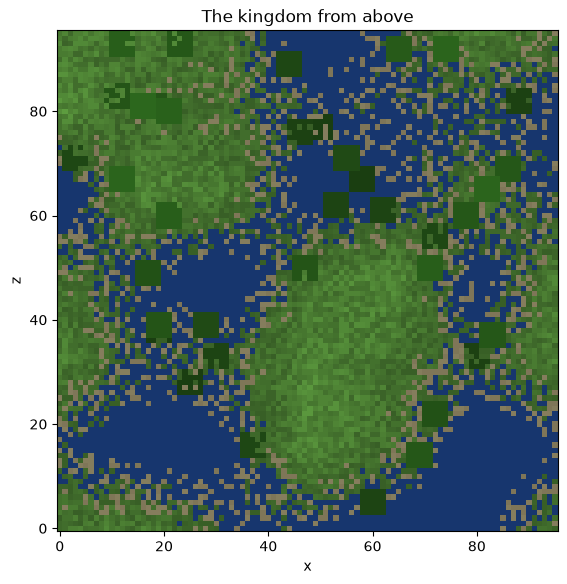

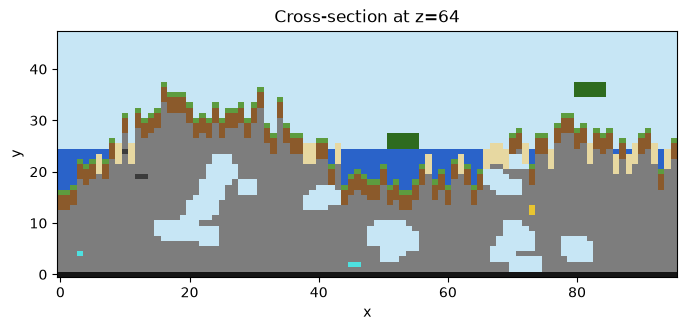

In [10]:
# ── A window into the kingdom (display helpers, no need to modify) ──
_PALETTE = ["#c7e6f5", "#7d7d7d", "#8b5a2b", "#5d9c3f", "#2a63c9", "#e7d8a1",
            "#6b4a1f", "#2e6b1e", "#3b3b3b", "#c9a075", "#e8c531", "#4ee1e0",
            "#1b1030", "#151515"]
_CMAP = ListedColormap(_PALETTE)

def top_view(w=None):
    w = world if w is None else w
    seen = (w[:, ::-1, :] != 0)
    ys = (w.shape[1] - 1) - seen.argmax(axis=1)
    blocks = w[np.arange(w.shape[0])[:, None], ys, np.arange(w.shape[2])[None, :]]
    shade = 0.55 + 0.45 * (ys - ys.min()) / max(1, ys.max() - ys.min())
    rgb = _CMAP(blocks / 13.0)[..., :3] * shade[..., None]
    plt.figure(figsize=(6.5, 6.5))
    plt.imshow(np.transpose(rgb, (1, 0, 2)), origin="lower")
    plt.xlabel("x"); plt.ylabel("z"); plt.title("The kingdom from above")
    plt.show()

def cross_section(axis="z", index=48):
    sl = world[:, :, index].T if axis == "z" else world[index, :, :]
    plt.figure(figsize=(8, 3.2))
    plt.imshow(sl if axis != "z" else sl, origin="lower", cmap=_CMAP, vmin=0, vmax=13,
               aspect="auto")
    plt.xlabel("x" if axis == "z" else "z"); plt.ylabel("y")
    plt.title(f"Cross-section at {axis}={index}")
    plt.show()

def peek_3d(x0, y0, z0, size=20):
    crop = world[x0:x0+size, y0:y0+size, z0:z0+size]
    filled = crop != 0
    colors = np.empty(crop.shape, dtype=object)
    for bid in np.unique(crop):
        colors[crop == bid] = _PALETTE[int(bid)]
    ax = plt.figure(figsize=(6, 6)).add_subplot(projection="3d")
    ax.voxels(np.transpose(filled, (0, 2, 1)),
              facecolors=np.transpose(colors, (0, 2, 1)), edgecolor=None)
    ax.set_title(f"world[{x0}:{x0+size}, {y0}:{y0+size}, {z0}:{z0+size}]")
    plt.show()

top_view()
cross_section("z", 64)

---
## **Part a: The Prospector's Ledger (30 points)**

The Treasury clerk arrives with an empty ledger and a nervous look. Nobody has paid block tax since the fire, because nobody can prove how many blocks anyone owns. The crown taxes only its own land, the **Royal Claim** (bounds in World Facts), and the law is blunt: every block id gets taxed, even air (the Ministry of Atmosphere insisted).

For **every block id from 0 to 13**, count how many blocks of that id lie inside the Royal Claim. That is 14 rows: `id` is the block id, `target` is its count.

Submission: `part1_submission.csv`, 14 rows, uploaded to part a.

In [11]:
part1 = pd.DataFrame({"id": np.arange(14), "target": 0})

# ── Your code starts here: fill part1["target"] ──
# The Royal Claim is x in [16, 80), z in [16, 80), y < 40. Python slices are
# already half-open, so the claim is exactly world[16:80, 0:40, 16:80].
claim = world[16:80, :40, 16:80]                     # shape (64, 40, 64)

# np.bincount counts how many times each integer appears in a flat array:
# counts[k] = number of blocks with id k. minlength=14 guarantees a slot for
# every id 0..13, even ids that never appear in the claim (count 0).
counts = np.bincount(claim.ravel(), minlength=14)
part1["target"] = counts[:14].astype(np.int64)

# Sanity check: every block of the claim is counted exactly once.
assert part1["target"].sum() == claim.size == 64 * 40 * 64
print("blocks in the Royal Claim:", claim.size)
part1["name"] = part1["id"].map(ID2NAME)   # readable view only, dropped before saving

part1[["id", "target"]].to_csv("part1_submission.csv", index=False)
part1

blocks in the Royal Claim: 163840


,id,target,name
0,0,55447,air
1,1,80457,stone
2,2,9888,dirt
3,3,3296,grass
4,4,5527,water
5,5,3200,sand
6,6,84,wood
7,7,1066,leaves
8,8,107,coal_ore
9,9,138,iron_ore


---
## **Part b: Peaks and Seabeds (35 points)**

The Cartographers' Guild lost every relief chart in the fire, and last week a merchant caravan discovered a cliff the old-fashioned way. The Guild wants the kingdom mapped chunk by chunk before anyone else does.

The kingdom divides into a 6 x 6 grid of 16 x 16 **chunks** (row-major index, see World Facts). For every chunk report two numbers, using the surface-height definition from World Facts:

- rows `id = 0..35`: the **highest** surface height in chunk `id` (the peak)
- rows `id = 36..71`: the **lowest** surface height in chunk `id - 36` (the seabed)

One warning from the Guild master: the last surveyor measured the top of the ocean and called it ground. He now surveys the ocean from the inside. Mind what counts as solid.

Submission: `part2_submission.csv`, 72 rows, uploaded to part b.

In [12]:
part2 = pd.DataFrame({"id": np.arange(72), "target": 0})

# ── Your code starts here: fill part2["target"] ──
# 1) Solid mask: everything except air (0) and water (4). Water is NOT ground,
#    otherwise every ocean column would report sea level instead of the seabed.
solid = (world != BLOCKS["air"]) & (world != BLOCKS["water"])   # (96, 48, 96) bool

# 2) Surface height = largest y that is solid. Flip the y axis so the topmost
#    block comes first; argmax returns the FIRST True along y, i.e. the highest
#    solid block counted from the top. Convert back: y = (H - 1) - index.
#    Every column has bedrock at y = 0, so argmax never sees an all-False column.
H = world.shape[1]
surface = (H - 1) - solid[:, ::-1, :].argmax(axis=1)            # (96, 96), indexed [x, z]

# 3) Chunks: x = 16*i + dx and z = 16*j + dz, so reshaping [x, z] -> [i, dx, j, dz]
#    groups every 16 x 16 chunk. Reducing over the in-chunk axes (dx, dz) gives a
#    (6, 6) grid indexed [i, j]; ravel() flattens it row-major -> index 6*i + j.
chunks = surface.reshape(6, 16, 6, 16)
peaks   = chunks.max(axis=(1, 3)).ravel()                        # ids 0..35
seabeds = chunks.min(axis=(1, 3)).ravel()                        # ids 36..71

part2["target"] = np.concatenate([peaks, seabeds]).astype(np.int64)

# Sanity checks: heights are valid y values and every peak >= its seabed.
assert surface.min() >= 0 and surface.max() < H
assert np.all(peaks >= seabeds)
print("surface height range:", surface.min(), "to", surface.max())
print("peaks:\n", peaks.reshape(6, 6), "\nseabeds:\n", seabeds.reshape(6, 6))

part2.to_csv("part2_submission.csv", index=False)
part2.head()

surface height range: 12 to 39
peaks:
 [[35 34 36 33 38 39]
 [35 28 32 37 38 38]
 [36 38 37 34 34 33]
 [35 38 37 37 29 34]
 [33 33 37 37 31 37]
 [30 32 35 37 37 36]] 
seabeds:
 [[15 13 19 14 14 26]
 [14 13 13 12 24 24]
 [16 14 12 13 17 13]
 [14 25 27 15 15 12]
 [13 15 18 17 17 17]
 [13 13 16 15 17 17]]


,id,target
0,0,35
1,1,34
2,2,36
3,3,33
4,4,38


---
## **Part c: The Buried Vault (35 points)**

With the census counted and the charts drawn, the Court Archaeologist finally gets her audience. The burned records mention a royal vault sealed centuries ago: a hollow cube of obsidian, walls one block thick, buried where no shovel would casually wander, with the crown's off-the-books gold inside. The Treasury, having just taxed everyone else, is extremely motivated to find its own money.

Everything known about the Vault is in World Facts. Find it and report:

| id | target |
|---|---|
| 0 | x coordinate of the Vault's center block |
| 1 | y coordinate of the Vault's center block |
| 2 | z coordinate of the Vault's center block |
| 3 | the Vault's outer edge length in blocks |
| 4 | the number of gold ore blocks in the hoard |

Submission: `part3_submission.csv`, 5 rows, uploaded to part c. When you have it, point `peek_3d` at your answer: the screenshot is the closest thing this course has to loot.

In [13]:
part3 = pd.DataFrame({"id": np.arange(5), "target": 0})

# ── Your code starts here: fill part3["target"] ──
# The Vault is the ONLY obsidian in the world, so the bounding box of all
# obsidian blocks is exactly the Vault's outer shell.
obs = np.argwhere(world == BLOCKS["obsidian"])      # (N, 3) array of [x, y, z]
lo = obs.min(axis=0)                                 # outer min corner
hi = obs.max(axis=0)                                 # outer max corner (inclusive)
edges = hi - lo + 1                                  # outer edge length per axis

# It is a cube: the three edge lengths must agree.
assert np.all(edges == edges[0]), f"not a cube: edges = {edges}"
edge = int(edges[0])

# Center block = midpoint of the inclusive bounds (exact when the edge is odd).
if edge % 2 == 0:
    print("warning: even edge length, the center block is ambiguous")
center = (lo + hi) // 2

# Sanity check: a hollow cube with 1-block walls has n^3 - (n-2)^3 shell blocks.
assert len(obs) == edge**3 - (edge - 2)**3, "obsidian is not a complete hollow shell"

# Hoard = gold ore strictly inside the walls: drop one layer on every side.
interior = world[lo[0] + 1:hi[0], lo[1] + 1:hi[1], lo[2] + 1:hi[2]]
gold = int((interior == BLOCKS["gold_ore"]).sum())

part3["target"] = [int(center[0]), int(center[1]), int(center[2]), edge, gold]
print(f"Vault corners {lo.tolist()} .. {hi.tolist()}, edge {edge}, "
      f"center {center.tolist()}, gold in hoard: {gold}")

part3.to_csv("part3_submission.csv", index=False)
part3

Vault corners [42, 3, 66] .. [50, 11, 74], edge 9, center [46, 7, 70], gold in hoard: 25


,id,target
0,0,46
1,1,7
2,2,70
3,3,9
4,4,25


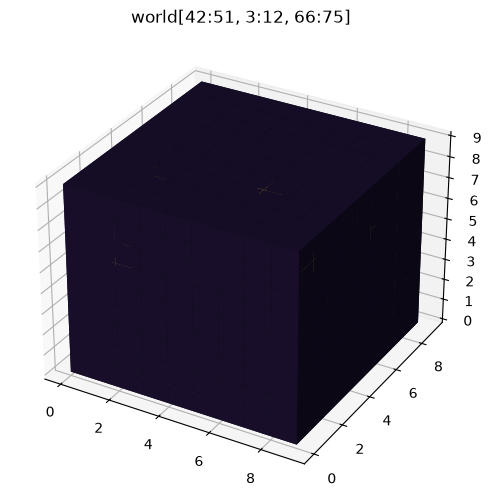

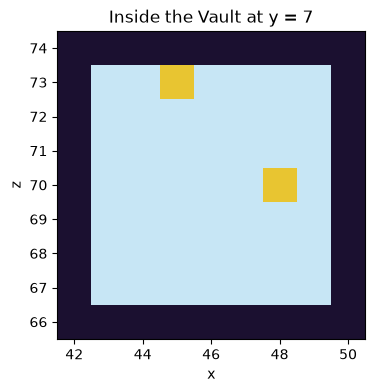

In [14]:
# ── Loot screenshot: the Vault, cropped exactly to its outer shell ──
peek_3d(int(lo[0]), int(lo[1]), int(lo[2]), size=edge)

# The walls hide the inside, so also slice through the center (y = center) to see the hoard.
plt.figure(figsize=(4, 4))
plt.imshow(world[lo[0]:hi[0] + 1, center[1], lo[2]:hi[2] + 1].T, origin="lower",
           cmap=_CMAP, vmin=0, vmax=13, extent=[lo[0] - 0.5, hi[0] + 0.5, lo[2] - 0.5, hi[2] + 0.5])
plt.xlabel("x"); plt.ylabel("z"); plt.title(f"Inside the Vault at y = {center[1]}")
plt.show()

---
## **Good luck, Surveyor**

The Treasury counts on you, the Guild charts by you, and the Archaeologist has already ordered a smaller shovel. partial credit on every part. Quills down, arrays up.